In [3]:
import numpy as np
from PIL import Image
import pandas as pd
import torchvision
import torch
import warnings
import os
from torch.utils.data import DataLoader, Dataset, random_split
import cv2
import matplotlib.pyplot as plt
from torchvision.io import decode_image
import seaborn as sns
warnings.filterwarnings("ignore")

In [4]:
train = pd.read_csv('/kaggle/input/uw-madison-gi-tract-image-segmentation/train.csv')
train

,id,class,segmentation
0,case123_day20_slice_0001,large_bowel,NaN
1,case123_day20_slice_0001,small_bowel,NaN
2,case123_day20_slice_0001,stomach,NaN
3,case123_day20_slice_0002,large_bowel,NaN
4,case123_day20_slice_0002,small_bowel,NaN
...,...,...,...
115483,case30_day0_slice_0143,small_bowel,NaN
115484,case30_day0_slice_0143,stomach,NaN
115485,case30_day0_slice_0144,large_bowel,NaN
115486,case30_day0_slice_0144,small_bowel,NaN


In [5]:
import gc
def empty_cached():
  gc.collect()
  torch.cuda.empty_cache()

In [6]:

train['missed'] =  train.segmentation.notna()
train['segm'] = ''

for i in range(0, train.shape[0], 3):
    train.segm.iloc[i] = train.iloc[i:i+3].segmentation.to_numpy()
    train.missed.iloc[i] = train.iloc[i:i+3].missed.any()
print(train.info())  

train = train[::3]
train.reset_index(drop = True, inplace = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115488 entries, 0 to 115487
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            115488 non-null  object
 1   class         115488 non-null  object
 2   segmentation  33913 non-null   object
 3   missed        115488 non-null  bool  
 4   segm          115488 non-null  object
dtypes: bool(1), object(4)
memory usage: 3.6+ MB
None


In [7]:

train['path'] = '/kaggle/input/uw-madison-gi-tract-image-segmentation/train/'
train['splitted'] = train.id.agg(lambda x: x.split('_'))
train['case']     = train.splitted.agg(lambda x: str(x[0]))
train['day']      = train.splitted.agg(lambda x: str(x[1]))
train['slice']    = train.splitted.agg(lambda x: int(x[3].lstrip('0')))


cases = train.case.value_counts(sort = False)
cases_val, case_iter = cases.index, cases.values
case_iter = np.insert(case_iter, 0, 0)
case_iter = np.cumsum(case_iter)

for i in range(1, case_iter.shape[0]):
    
    temp_data = train.iloc[case_iter[i-1]:case_iter[i]]
    train.path.iloc[case_iter[i-1]:case_iter[i]] +=  cases_val[i-1]

    days = temp_data.day.value_counts(sort = False)
    day_val, day_iter = days.index, days.values
    day_iter = np.insert(day_iter, 0, 0)
    day_iter = np.cumsum(day_iter)

    for j in range(1, day_iter.shape[0]):
        
        val = '/'+cases_val[i-1]+'_'+day_val[j-1]+'/'+'scans/'
        train.path.iloc[case_iter[i-1]+day_iter[j-1]:day_iter[j]+case_iter[i-1]] +=  val

        list_of_files = sorted(os.listdir(train.path.iloc[case_iter[i-1]+day_iter[j-1]]))
        '''
        list_of_files = np.repeat(list_of_files, 
                                  np.ones(len(list_of_files), dtype = np.int8)*3)
        '''
        train.path.iloc[case_iter[i-1]+day_iter[j-1]:day_iter[j]+case_iter[i-1]] +=  list_of_files
        

In [8]:
indexes = train[train['missed'] == True].index

train['not missed_classes'] = 'noone classes'
train['not missed_classes'].iloc[indexes] == 'all classes'


train['stomach'] = False
train['large_bowel'] = False
train['small_bowel'] = False

missed_classes = np.array(['large_bowel\n', 'small_bowel\n', 'stomach'])
for i in indexes:

    states = pd.notnull(train.segm.iloc[i])
   
    train['large_bowel'].iloc[i] = states[0]
    train['small_bowel'].iloc[i] = states[1]
    train['stomach'].iloc[i] = states[2]

    states = np.where(states)[0]
    
    missed_class = "  ".join(missed_classes[states].tolist())
    train['not missed_classes'].iloc[i] = missed_class

    

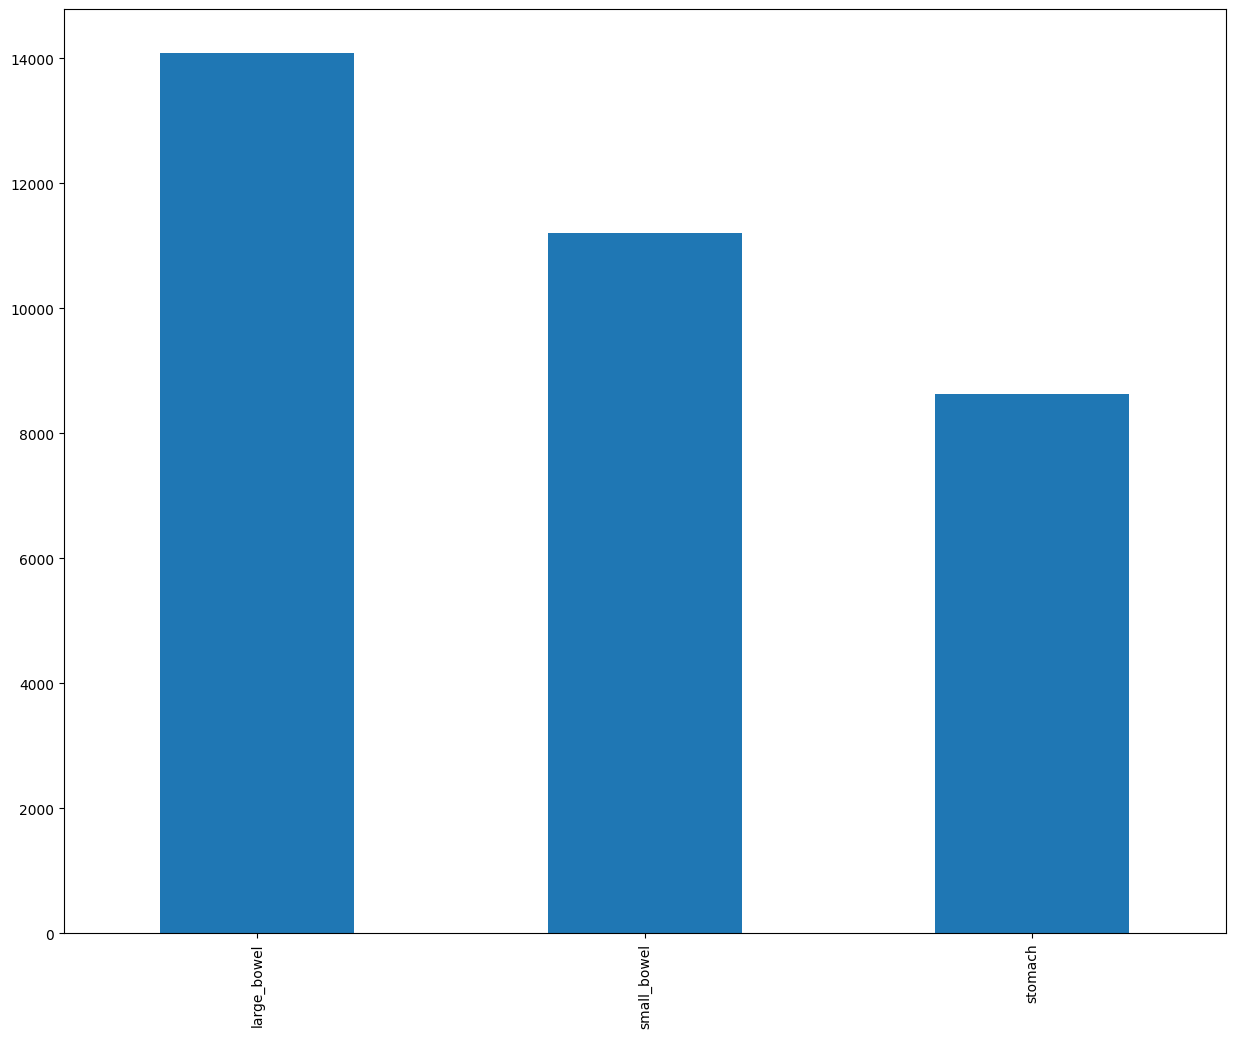

In [9]:
fig, ax = plt.subplots(figsize=(15, 12))
train[['large_bowel', 'small_bowel', 'stomach']].sum().plot.bar()
plt.show()

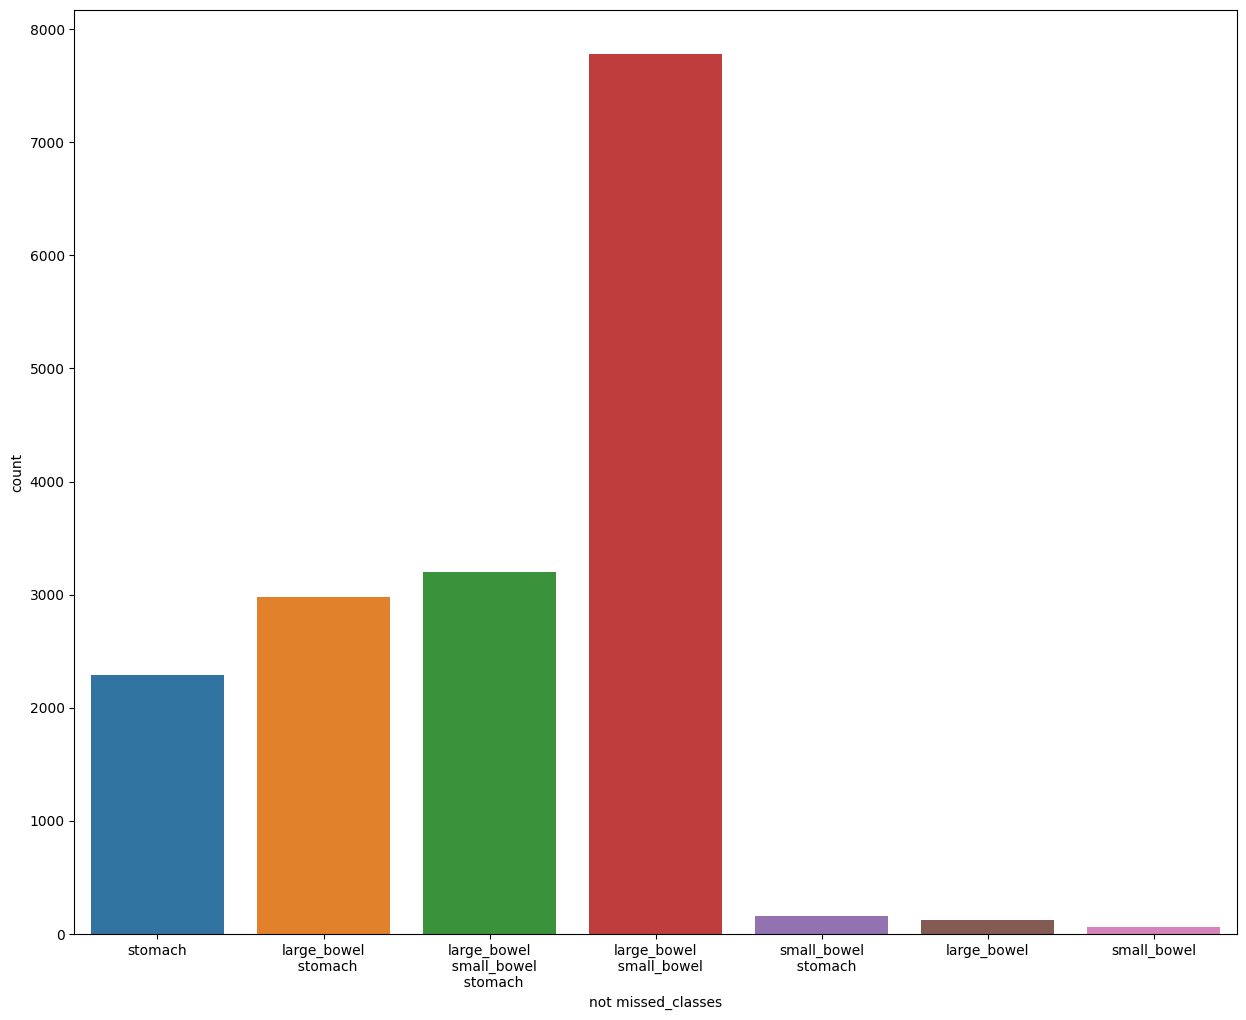

In [10]:
fig, ax = plt.subplots(figsize=(15, 12))
ax = sns.countplot(data = train.iloc[indexes], x = 'not missed_classes' )
plt.show()

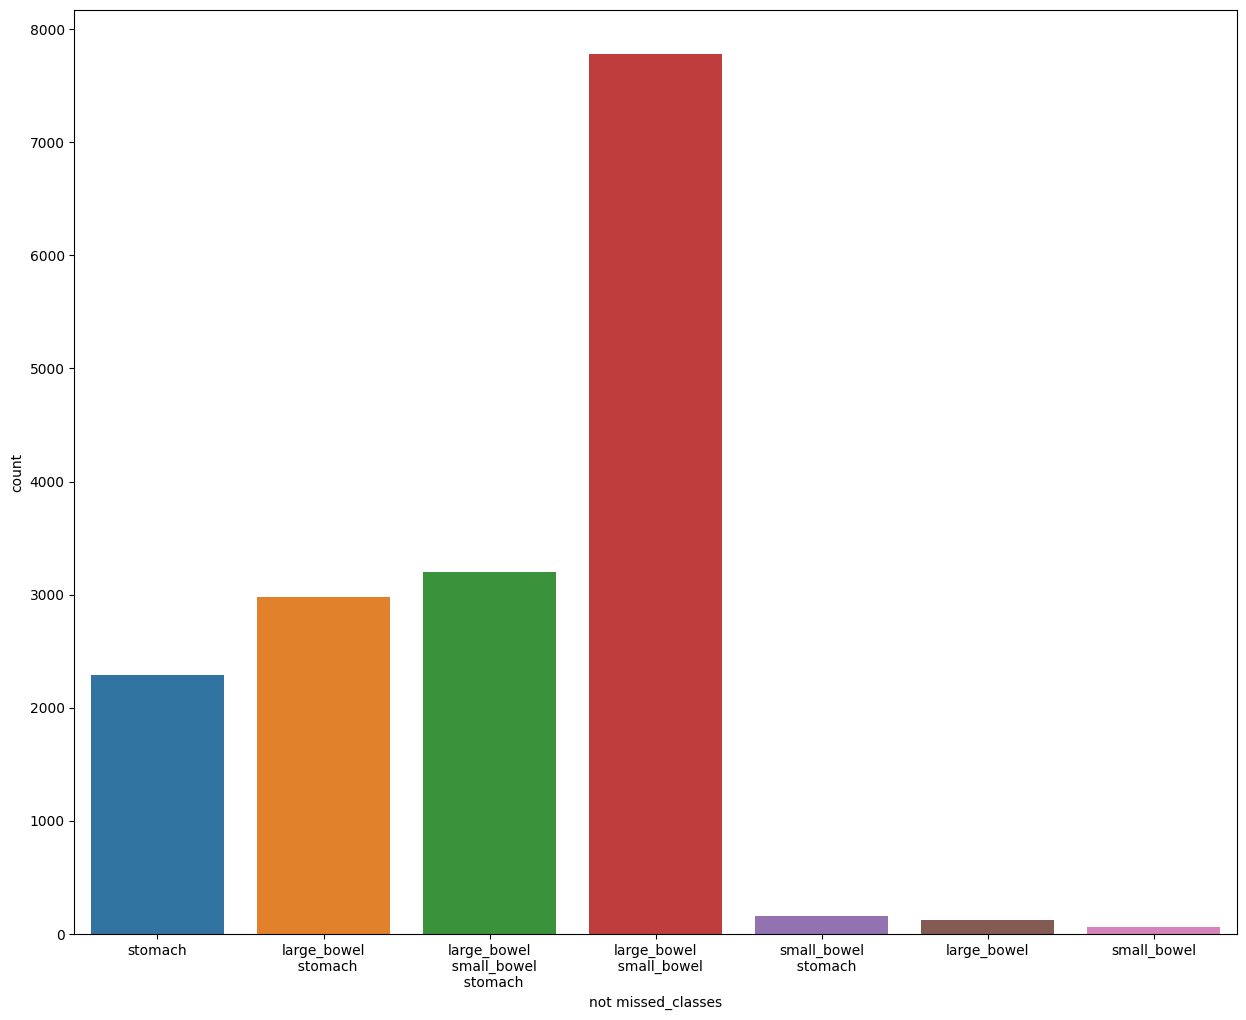

In [11]:
fig, ax = plt.subplots(figsize=(15, 12))
ax = sns.countplot(data = train.iloc[indexes], x = 'not missed_classes' )
plt.show()

In [9]:

#to_drop = ['class', 'segmentation', 'splitted', 'case', 'day', 'slice']
#train.drop(columns = to_drop, inplace = True)
#print(train.info())
#train.head()

train_og = train.copy()
train = train[train['missed'] == True]
train.reset_index(drop=True, inplace = True)
train

,id,class,segmentation,missed,segm,path,splitted,case,day,slice,not missed_classes,stomach,large_bowel,small_bowel
0,case123_day20_slice_0065,large_bowel,NaN,True,"[nan, nan, 28094 3 28358 7 28623 9 28889 9 291...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0065]",case123,day20,65,stomach,True,False,False
1,case123_day20_slice_0066,large_bowel,NaN,True,"[nan, nan, 27561 8 27825 11 28090 13 28355 14 ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0066]",case123,day20,66,stomach,True,False,False
2,case123_day20_slice_0067,large_bowel,NaN,True,"[nan, nan, 15323 4 15587 8 15852 10 16117 11 1...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0067]",case123,day20,67,stomach,True,False,False
3,case123_day20_slice_0068,large_bowel,NaN,True,"[nan, nan, 14792 5 15056 9 15321 11 15587 11 1...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0068]",case123,day20,68,stomach,True,False,False
4,case123_day20_slice_0069,large_bowel,NaN,True,"[nan, nan, 14526 6 14789 12 15054 14 15319 16 ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0069]",case123,day20,69,stomach,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16585,case30_day0_slice_0133,large_bowel,17695 8 17957 23 18213 39 18477 45 18741 52 19...,True,[17695 8 17957 23 18213 39 18477 45 18741 52 1...,/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0133]",case30,day0,133,large_bowel\n small_bowel\n,False,True,True
16586,case30_day0_slice_0134,large_bowel,17694 5 17957 10 18215 2 18219 17 18478 32 187...,True,[17694 5 17957 10 18215 2 18219 17 18478 32 18...,/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0134]",case30,day0,134,large_bowel\n small_bowel\n,False,True,True
16587,case30_day0_slice_0135,large_bowel,17957 1 18219 10 18482 16 18744 23 19008 43 19...,True,[17957 1 18219 10 18482 16 18744 23 19008 43 1...,/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0135]",case30,day0,135,large_bowel\n small_bowel\n,False,True,True
16588,case30_day0_slice_0136,large_bowel,18746 7 19009 23 19038 7 19273 44 19537 49 198...,True,[18746 7 19009 23 19038 7 19273 44 19537 49 19...,/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0136]",case30,day0,136,large_bowel\n small_bowel\n,False,True,True


<Axes: xlabel='case', ylabel='count'>

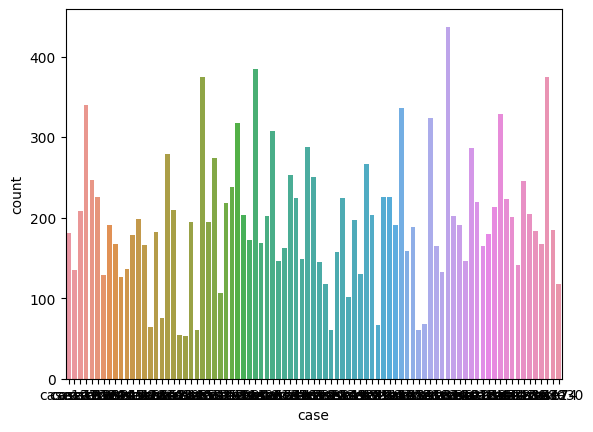

In [119]:
sns.countplot(x='case', data=train)

In [10]:
train['image_shape'] = pd.NA 

for i in range(train.shape[0]):

     train.image_shape.iloc[i] = train.path.iloc[i][-21:-14]

print(train.image_shape.value_counts())

image_shape
266_266    10955
360_310     4861
276_276      718
234_234       56
Name: count, dtype: int64


In [11]:
data_360 = train[train['image_shape'] == '360_310']
data_360.case.unique()
data_360.reset_index(drop=True, inplace=True)

cases = data_360.case.value_counts(sort = False)
cases_val, case_iter = cases.index, cases.values
case_iter = np.insert(case_iter, 0, 0)
case_iter = np.cumsum(case_iter)

fig,ax = plt.subplots(5, 5, figsize = (16, 18), dpi = 600)
for i in range(5):
    for j in range(1, 6):
        image = cv2.imread(data_360.path.iloc[case_iter[(i*(j-1))+j-1]], 
                           cv2.IMREAD_ANYDEPTH)
        ax[i, j-1].imshow(image, cmap = 'gray')
        ax[i, j-1].axis('off')
    
    


In [29]:
data_276 = train[train['image_shape'] == '276_276']
data_276.case.unique()
data_276.reset_index(drop=True, inplace=True)

cases = data_276.case.value_counts(sort = False)
cases_val, case_iter = cases.index, cases.values
case_iter = np.insert(case_iter, 0, 0)
case_iter = np.cumsum(case_iter)

fig,ax = plt.subplots(4, 2, figsize = (16, 18), dpi = 600)
for i in range(4):
    for j in range(1, 3):
        image = cv2.imread(data_276.path.iloc[case_iter[(i*(j-1))+j-1]], 
                           cv2.IMREAD_ANYDEPTH)
        ax[i, j-1].imshow(image, cmap = 'gray')
        ax[i, j-1].axis('off')

In [19]:
def find_contour(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)[1]
    #thresh = cv2.erode(thresh, None, iterations=2)
    #thresh = cv2.dilate(thresh, None, iterations=2)

    cnts, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = max(cnts, key=cv2.contourArea)

    extreme_point = []
    extLeft = tuple(c[c[:,:,0].argmin()][0]); extreme_point.append(extLeft)
    extRight = tuple(c[c[:,:,0].argmax()][0]); extreme_point.append(extRight)
    extTop = tuple(c[c[:,:,1].argmin()][0]); extreme_point.append(extTop) 
    extBot = tuple(c[c[:,:,1].argmax()][0]); extreme_point.append(extBot)
    
    img_cnt = cv2.drawContours(img.copy(), c, -1, (0,255,255), 3)

    img_pnt = cv2.circle(img_cnt.copy(), extLeft, 5, (0, 0, 255), -1)
    img_pnt = cv2.circle(img_pnt, extRight, 5, (0, 255, 0), -1)
    img_pnt = cv2.circle(img_pnt, extTop, 5, (255, 0, 0), -1)
    img_pnt = cv2.circle(img_pnt, extBot, 5, (255, 255, 0), -1)
    
    return img_pnt, extreme_point

def crop_img(img, extreme_point):
    
    new_img = img[extreme_point[2][1]:extreme_point[3][1], extreme_point[0][0]:extreme_point[1][0]]
    
    return new_img

def remove_noise(img, extreme_point):

    new_img = np.zeros((img.shape[0],img.shape[1], img.shape[2]), dtype=np.uint8)
    
    new_img[extreme_point[2][1]:extreme_point[3][1], extreme_point[0][0]:extreme_point[1][0]] = img[extreme_point[2][1]:extreme_point[3][1], extreme_point[0][0]:extreme_point[1][0]]
    
    return new_img


In [12]:
test_cases = train.case.value_counts(ascending=True)[:20].index
test_cases

test_set = train[train['case'].isin(test_cases)]

train_set = train[~train['case'].isin(test_cases)]


<Axes: xlabel='case', ylabel='count'>

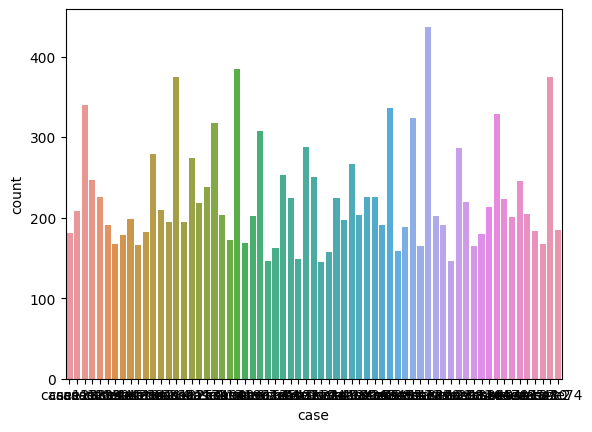

In [61]:
sns.countplot(data = train_set, x = 'case')

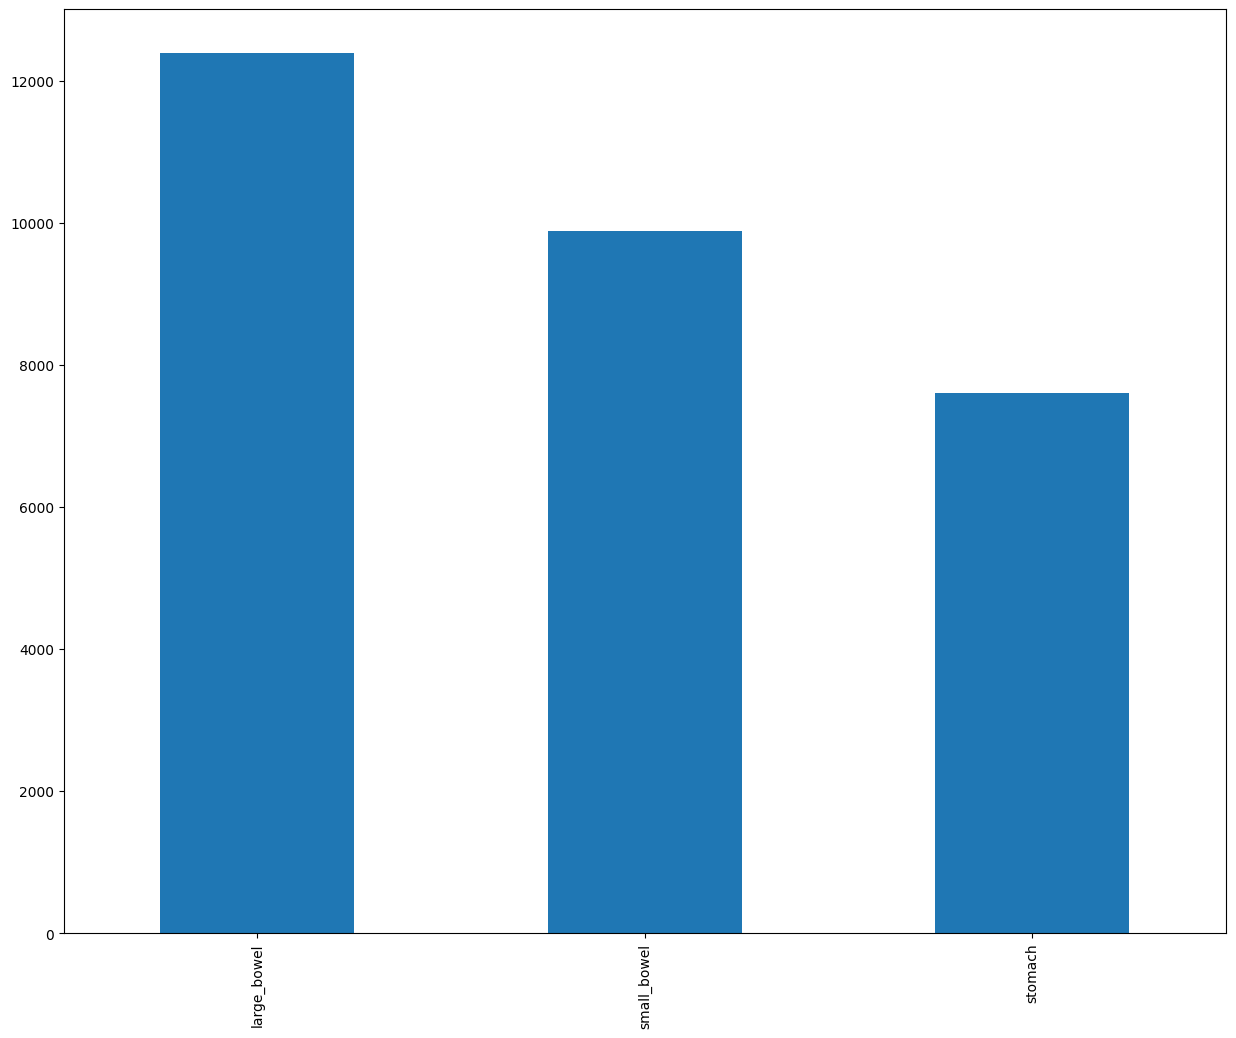

In [63]:
fig, ax = plt.subplots(figsize=(15, 12))
train_set[['large_bowel', 'small_bowel', 'stomach']].sum().plot.bar()
plt.show()

<Axes: xlabel='case', ylabel='count'>

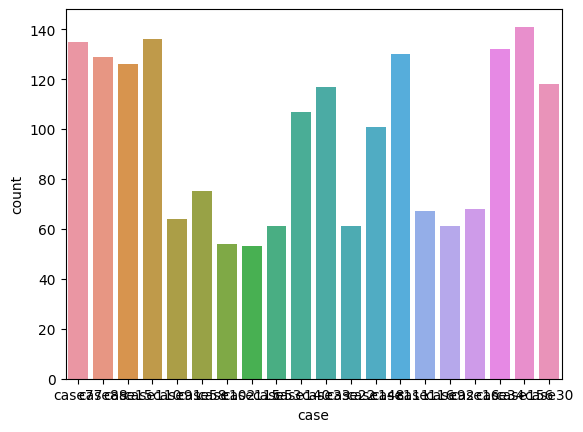

In [62]:
sns.countplot(data = test_set, x = 'case')

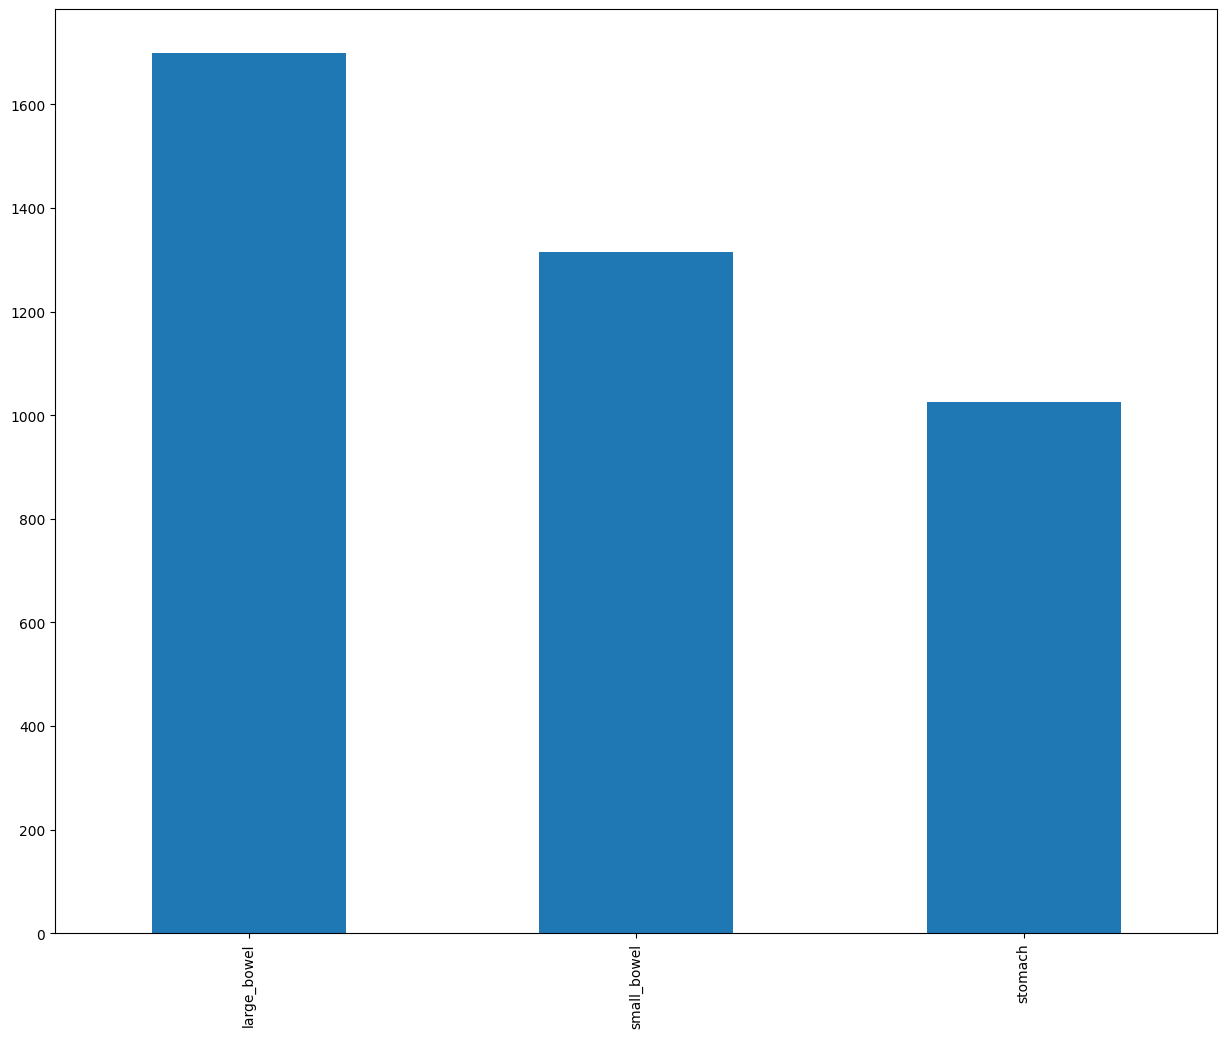

In [64]:
fig, ax = plt.subplots(figsize=(15, 12))
test_set[['large_bowel', 'small_bowel', 'stomach']].sum().plot.bar()
plt.show()

In [13]:

#size_of_image = width*heigth

def get_file(file_id,
             parent_dir = '/kaggle/input/uw-madison-gi-tract-image-segmentation/train/'):
    'file_IDs look like case(int)_day(int)_slice_(int)'
    'corresponding images are placed in directory case(int)/case(int)_day(int)/scans/slice....png'

    #splitting our string to obtain list [case(int), day(int), slice, (int)]
    path = file_id.split('_')

    #appending case(int) to the beggining of day(int) to obtain case(int)_day(int)
    path[1] = path[0] + '_' + path[1]
    #replacing 'slice' by 'scans' 
    path[2] = 'scans'
    'Now we have list [case(int), case(int)_day(int), scans, (int)] and we are able to construct path'
    'to a corresponding folder of image'
    
    #'parent_dir/case(int)/case(int)_day(int)/scans/
    index = path[-1]
    path = parent_dir+'/'.join(path[:-1])+'/'
    list_of_pngs = os.listdir(path)

    #to obtain necessery file from list of pngs, first of all, we delete zeros from left side of index
    #then we convert it to integer and substracting from it 1 to make an appropriate indexation 
    ind = int(index.lstrip('0'))-1
    
    
    return path+list_of_pngs[ind]



def RLE_masking(rle, shape = (266, 266)):
    
    if pd.isna(rle):
        return torch.zeros(shape[0], shape[1])

    size_of_image = shape[0]*shape[1]

    rle = list(map(int, rle.split()))
        
    start_pixel, len_of_masking = rle[::2], rle[1::2]
    mask = torch.zeros(size_of_image)
    
    masking = torch.hstack([torch.arange(start_pixel[i], start_pixel[i]+len_of_masking[i] + 1) 
                        for i in range(len(start_pixel))]) - 1

    mask[masking] = 1
    mask = torch.reshape(mask, (shape[0], shape[1]))
    
    return mask



In [14]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
batch_size = 16

In [55]:
import torchvision.transforms as transforms
import torch.nn.functional as F

class ImageDataset(Dataset):
    def __init__(self, data, transform = None):
        
        super().__init__()
        
        self.data = data
        self.transform = transform

    
    def __len__(self):
        return len(self.data)

    
    def __getitem__(self, idx):
        item = self.data.iloc[idx]    
        image = cv2.imread(item['path'], cv2.IMREAD_ANYDEPTH)/65355
             
        masks = []
        segmentation = item['segm']
        image = torch.tensor(image)
        
        for i in range(3):
            masks.append(RLE_masking(segmentation[i], image.shape))

        if ((image.shape[0] != 266) or (image.shape[1] != 266)):
            image = image.unsqueeze(0).unsqueeze(0)
            image = F.interpolate(image, (266,266))
            image = image.squeeze(0).squeeze(0)
            for i in range(3):
                masks[i] = masks[i].unsqueeze(0).unsqueeze(0)
                masks[i] = F.interpolate(masks[i], (266,266))
                masks[i] = masks[i].squeeze(0).squeeze(0)
        
        masks = torch.stack(masks, dim=0)
        
        image, masks = image.to(torch.half), masks.to(torch.half)

        return {'image': image, 'masks': masks}
    

train_dataloader = DataLoader(ImageDataset(train_set), shuffle=True, batch_size=batch_size)
valid_dataloader = DataLoader(ImageDataset(test_set), shuffle=True, batch_size=batch_size)

In [40]:
from torch.nn.functional import pad, one_hot

In [63]:
from torch import nn


class Right(nn.Module):
    def __init__(self, 
               in_chan, out_chan):
        
        super(Right, self).__init__()
        
        self.conv_1 = nn.Conv2d(in_chan, out_chan, kernel_size = 3)
        torch.nn.init.xavier_uniform_(self.conv_1.weight)
        self.conv_2 = nn.Conv2d(out_chan, out_chan, kernel_size = 3)
        torch.nn.init.xavier_uniform_(self.conv_2.weight)
        self.BN = nn.BatchNorm2d(out_chan)
        #self.relu = nn.ReLU()
        self.relu = nn.LeakyReLU(0.1)

    
    def forward(self, _input):

            x = self.conv_1(_input)
            x = self.BN(x)
            x = self.relu(x)
            
            x = self.conv_2(x)
            x = self.BN(x)
            output = self.relu(x)

            
            return output



class Down(nn.Module):
    def __init__(self, 
               in_chan, out_chan):
        
        super(Down, self).__init__() 

        self.down_step = nn.Sequential(
                nn.MaxPool2d(2),
                Right(in_chan, out_chan)
        )

    def forward(self, _input):
        
            return self.down_step(_input)


class Up(nn.Module):
    def __init__(self, 
               in_chan, out_chan):
        
        super(Up, self).__init__() 

        self.up = nn.ConvTranspose2d(in_chan, in_chan // 2, kernel_size=2)
        self.conv = Right(in_chan, out_chan)    
        

    def forward(self, input1, input2):
            
        x1 = self.up(input1)
        
        diffY = input2.size()[2] - x1.size()[2]
        diffX = input2.size()[3] - x1.size()[3]

        x1 = pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        x = torch.cat([input2, x1], dim=1)
        return self.conv(x)




class Out(nn.Module):
    def __init__(self, 
               in_chan, out_chan):
        
        super(Out, self).__init__() 

        self.conv = nn.Conv2d(in_chan, out_chan, kernel_size = 1)  

    def forward(self, x):
        return self.conv(x)




class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        self.inc = Right(n_channels, out_chan = 64)
        
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        
        self.outc = Out(64, n_classes)

        self.log = nn.Softmax()

    def forward(self, x):
        x = x.view(x.shape[0], 1, 266,266)


        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)

        
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        self.outc = torch.utils.checkpoint(self.outc)

model = UNet(n_channels = 1, n_classes = 3).to(dtype=torch.half, device='cuda')

In [61]:

from torchmetrics.segmentation import GeneralizedDiceScore


loss_fn = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3,weight_decay=1e-2) 

def metrics(n_classes,
            pred, true, eps= 0.001):
    M = torch.zeros(n_classes)

    for i in range(n_classes):
        a = 2*torch.sum(pred[:, i, :, :]*true[:, i, :, :])
        b = torch.sum(pred[:, i, :, :] + true[:, i, :, :] + 0.0011, (2, 1)) 
        M[i] = torch.mean(a/b)

    return M

In [ ]:
import tqdm
epochs = 10

for i in range(epochs):
    print(f"Epoch {i}")
    
    train_tqdm = tqdm.tqdm(train_dataloader)
    model.train()
    
    for batch in train_tqdm:
        image, masks = batch['image'], batch['masks']
        masks = masks[:, :, :258, :258]
        image, masks = image.to(device), masks.to(device) 
    
        optimizer.zero_grad()  #Обнуляем везде градиенти
        model.zero_grad()
        
        output = model(image)
        L = loss_fn(output, masks)#Рахуємо втрати
        output, masks = output.cpu(), masks.cpu()
        
        M = metrics(3, output, masks)
 

        L.backward()   #Градієнт втрат
        nn.utils.clip_grad_value_(model.parameters(), clip_value=0.1)

        optimizer.step()   #Оновлюємо ваги в нейронці
        train_tqdm.set_description(f"Train loss: {L.item()}  Metrics loss: {M[0]}-{M[1]}-{M[2]}") #Виводимо в термінал інформацію про втрати
        train_tqdm.refresh() #Оновлюємо для кожного батчу термінал 


    model.eval()
    valid_metrics = torch.tensor([0, 0, 0], dtype = torch.float)
    val_loss = []
    
    test_tqdm = tqdm.tqdm(valid_dataloader)
    with torch.no_grad():
        for batch in test_tqdm:
            image, masks = batch['image'], batch['masks']
            image, masks = image.to(device), masks.to(device) 
            
            output = model(image)
            L = loss_fn(output, masks)
            val_loss.append(L.item())
            
            output, masks = output.cpu(), masks.cpu()
            M = metrics(3, output, masks)
            
            valid_metrics = torch.vstack((valid_metrics, M))

    print(f"Epoch {i}, Loss: {np.mean(val_loss)} Metrics: {torch.mean(valid_metrics[1:, :], axis = 0)}")

Epoch 0


Train loss: 0.662109375  Metrics loss: 0.7314453125-1.3427734375-0.004055023193359375:  76%|███████▌  | 693/916 [06:44<02:26,  1.53it/s] 

In [210]:
print(torchvision.__version__)

0.16.2


In [91]:
empty_cached()

In [ ]:
f = train_1.iloc[53]
fig, ax = plt.subplots()

image = cv2.imread(f.path, 
                           cv2.IMREAD_ANYDEPTH)
ax.imshow(image, cmap = 'gray')
  



mask1 = RLE_masking(f.segm[0],
                           image.shape)
mask2 = RLE_masking(f.segm[1],
                           image.shape)
mask3 = RLE_masking(f.segm[2],
                           image.shape)
        


ax.imshow(image, cmap = 'gray')
        
ax.imshow(mask1, alpha = 0.50, )
ax.imshow(mask2, alpha = 0.50)
ax.imshow(mask3, alpha = 0.50)
ax.axis('off')